In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

ROOT = Path.cwd().parent
DATA_PATH = ROOT / "data" / "processed" / "hotel_bookings_clean.csv"
VISUALS_DIR = ROOT / "visuals"
VISUALS_DIR.mkdir(exist_ok=True)

# one consistent look for every chart in the project
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.titleweight"] = "bold"

# load, telling pandas that arrival_date is a real date
df = pd.read_csv(DATA_PATH, parse_dates=["arrival_date"])

# CSV files forget category order, so restore it (needed for sorted charts)
lead_order = ["0-7d", "8-30d", "31-90d", "91-180d", "181-365d", "365d+"]
season_order = ["Winter", "Spring", "Summer", "Autumn"]
df["lead_time_group"] = pd.Categorical(df["lead_time_group"], categories=lead_order, ordered=True)
df["season"] = pd.Categorical(df["season"], categories=season_order, ordered=True)

print(df.shape)
print(df["lead_time_group"].value_counts().sort_index())

(86637, 42)
lead_time_group
0-7d        17855
8-30d       16234
31-90d      22633
91-180d     18190
181-365d    11164
365d+         561
Name: count, dtype: int64


In [30]:
df.T

,0,1,2,3,4,5,6,7,8,9,...,86627,86628,86629,86630,86631,86632,86633,86634,86635,86636
hotel,Resort Hotel,Resort Hotel,Resort Hotel,Resort Hotel,Resort Hotel,Resort Hotel,Resort Hotel,Resort Hotel,Resort Hotel,Resort Hotel,...,City Hotel,City Hotel,City Hotel,City Hotel,City Hotel,City Hotel,City Hotel,City Hotel,City Hotel,City Hotel
is_canceled,0,0,0,0,0,1,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
lead_time,7,13,14,0,9,85,75,23,35,68,...,44,188,135,164,21,23,102,34,109,205
arrival_date_year,2015,2015,2015,2015,2015,2015,2015,2015,2015,2015,...,2017,2017,2017,2017,2017,2017,2017,2017,2017,2017
arrival_date_month,July,July,July,July,July,July,July,July,July,July,...,August,August,August,August,August,August,August,August,August,August
arrival_date_week_number,27,27,27,27,27,27,27,27,27,27,...,35,35,35,35,35,35,35,35,35,35
arrival_date_day_of_month,1,1,1,1,1,1,1,1,1,1,...,31,31,30,31,30,30,31,31,31,29
stays_in_weekend_nights,0,0,0,0,0,0,0,0,0,0,...,1,2,2,2,2,2,2,2,2,2
stays_in_week_nights,1,1,2,2,2,3,3,4,4,4,...,3,3,4,4,5,5,5,5,5,7
adults,1,1,2,2,2,2,2,2,2,2,...,2,2,3,2,2,2,3,2,2,2


In [31]:
cancel_rate = df["is_canceled"].mean()*100
hotel_share = df["hotel"].value_counts()


print(f"Total bookings: {len(df):,}")
print(f"Cancelled: {df['is_canceled'].sum():,} ({cancel_rate:.1f}%)")
print(f"Kept: {(df['is_canceled']==0).sum():,} ({100-cancel_rate:.1f}%)")
print(hotel_share.to_string())


Total bookings: 86,637
Cancelled: 23,985 (27.7%)
Kept: 62,652 (72.3%)
hotel
City Hotel      53042
Resort Hotel    33595


Text(0, 0.5, 'Number of bookings')

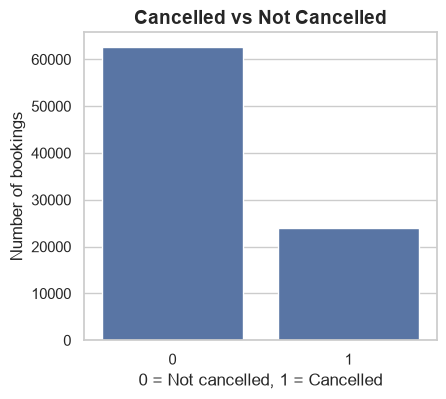

In [32]:
# Step 2: make an empty canvas
plt.figure(figsize=(10, 4))

# Step 3: left chart
plt.subplot(1, 2, 1)
sns.countplot(x="is_canceled", data=df)
plt.title("Cancelled vs Not Cancelled")
plt.xlabel("0 = Not cancelled, 1 = Cancelled")
plt.ylabel("Number of bookings")

About 1 in 4 bookings is cancelled, and that is the problem this project tackles.

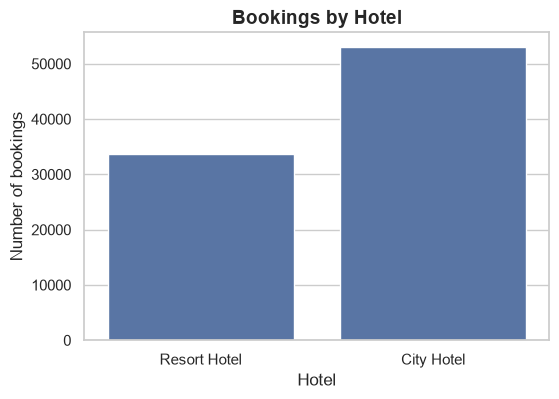

In [33]:
plt.figure(figsize=(6, 4))
sns.countplot(x="hotel", data=df)
plt.title("Bookings by Hotel")
plt.xlabel("Hotel")
plt.ylabel("Number of bookings")
plt.show()

The City Hotel has far more bookings than the Resort Hotel, so later we'll check whether the two behave differently.

In [34]:
plt.tight_layout()
plt.savefig(VISUALS_DIR / "01_cancellation_and_hotel_split.png")
plt.show()

<Figure size 800x500 with 0 Axes>

In [35]:
# lead time and ADR
print(df["lead_time"].describe().round(1))
print()
print(df["adr"].describe().round(1))


count    86637.0
mean        80.3
std         86.1
min          0.0
25%         12.0
50%         50.0
75%        126.0
max        709.0
Name: lead_time, dtype: float64

count    86637.0
mean       107.2
std         51.3
min          0.0
25%         72.9
50%         99.0
75%        134.4
max        510.0
Name: adr, dtype: float64


In [36]:
plt.figure(figsize=(12, 4))

<Figure size 1200x400 with 0 Axes>

<Figure size 1200x400 with 0 Axes>

Text(0, 0.5, 'Number of bookings')

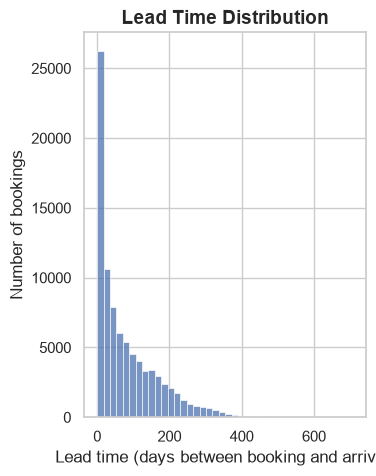

In [37]:
# Step 3: left chart (lead time)
plt.subplot(1, 2, 1)
sns.histplot(x="lead_time", data=df, bins=40)
plt.title("Lead Time Distribution")
plt.xlabel("Lead time (days between booking and arrival)")
plt.ylabel("Number of bookings")

Text(0, 0.5, 'Number of bookings')

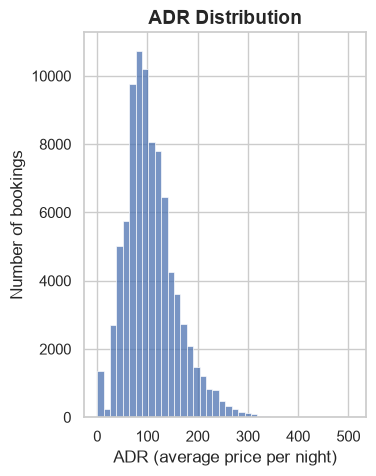

In [38]:
# Step 4: right chart (ADR)
plt.subplot(1, 2, 2)
sns.histplot(x="adr", data=df, bins=40)
plt.title("ADR Distribution")
plt.xlabel("ADR (average price per night)")
plt.ylabel("Number of bookings")

People usually book closer to their arrival date.
The average booking time is 80 days, but the middle value (median) is only 50 days. This means a few people book very, very early, which makes the average bigger. So, 50 days is a better idea of a typical booking.

Many people book at the last minute.
About 20.6% of bookings are made within 7 days of arrival. On the other hand, only 13.5% are booked more than 6 months in advance. So, the hotel gets both last-minute guests and early planners.

Most rooms cost around €100 per night.
Most bookings have prices between about €73 and €134 per night. Some rooms cost much more, probably because they are premium rooms or are booked during busy/peak seasons.

Some bookings have a price of €0.
About 1,052 bookings show €0 per night. These could be free/complimentary stays or special bookings. We won't remove them yet, but we should be careful because they can affect revenue calculations later.

In [39]:
plt.tight_layout()
plt.savefig(VISUALS_DIR / "02_lead_time_and_adr.png")
plt.show()

<Figure size 800x500 with 0 Axes>

In [40]:
df.T

,0,1,2,3,4,5,6,7,8,9,...,86627,86628,86629,86630,86631,86632,86633,86634,86635,86636
hotel,Resort Hotel,Resort Hotel,Resort Hotel,Resort Hotel,Resort Hotel,Resort Hotel,Resort Hotel,Resort Hotel,Resort Hotel,Resort Hotel,...,City Hotel,City Hotel,City Hotel,City Hotel,City Hotel,City Hotel,City Hotel,City Hotel,City Hotel,City Hotel
is_canceled,0,0,0,0,0,1,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
lead_time,7,13,14,0,9,85,75,23,35,68,...,44,188,135,164,21,23,102,34,109,205
arrival_date_year,2015,2015,2015,2015,2015,2015,2015,2015,2015,2015,...,2017,2017,2017,2017,2017,2017,2017,2017,2017,2017
arrival_date_month,July,July,July,July,July,July,July,July,July,July,...,August,August,August,August,August,August,August,August,August,August
arrival_date_week_number,27,27,27,27,27,27,27,27,27,27,...,35,35,35,35,35,35,35,35,35,35
arrival_date_day_of_month,1,1,1,1,1,1,1,1,1,1,...,31,31,30,31,30,30,31,31,31,29
stays_in_weekend_nights,0,0,0,0,0,0,0,0,0,0,...,1,2,2,2,2,2,2,2,2,2
stays_in_week_nights,1,1,2,2,2,3,3,4,4,4,...,3,3,4,4,5,5,5,5,5,7
adults,1,1,2,2,2,2,2,2,2,2,...,2,2,3,2,2,2,3,2,2,2


In [41]:
# guest and booking types

for col in ["market_segment" , "customer_type","deposit_type","meal"]:
     print((df[col].value_counts(normalize=True) * 100).round(1))
     print()

market_segment
Online TA        59.2
Offline TA/TO    15.9
Direct           13.4
Groups            5.6
Corporate         4.8
Complementary     0.8
Aviation          0.3
Undefined         0.0
Name: proportion, dtype: float64

customer_type
Transient          82.4
Transient-Party    13.4
Contract            3.6
Group               0.6
Name: proportion, dtype: float64

deposit_type
No Deposit    98.7
Non Refund     1.2
Refundable     0.1
Name: proportion, dtype: float64

meal
BB    77.8
SC    11.3
HB    10.4
FB     0.4
Name: proportion, dtype: float64



In [42]:
plt.figure(figsize=(12, 8))

<Figure size 1200x800 with 0 Axes>

<Figure size 1200x800 with 0 Axes>

Text(0, 0.5, 'Market segment')

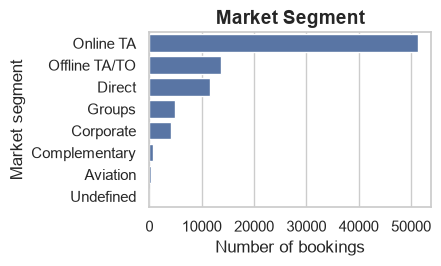

In [43]:
plt.subplot(2, 2, 1)
sns.countplot(y="market_segment", data=df, order=df["market_segment"].value_counts().index)
plt.title("Market Segment")
plt.xlabel("Number of bookings")
plt.ylabel("Market segment")

Online travel agents (Booking.com, Expedia and similar) bring in about 59% of bookings. The hotel relies heavily on third-party platforms. These platforms often offer free cancellation, which could be linked to cancellations.

Text(0, 0.5, 'Customer type')

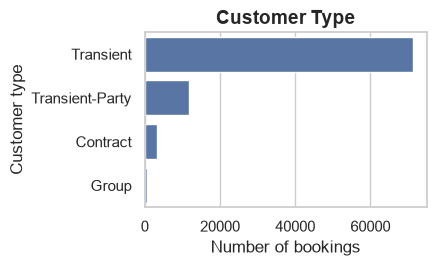

In [44]:
plt.subplot(2, 2, 2)
sns.countplot(y="customer_type", data=df, order=df["customer_type"].value_counts().index)
plt.title("Customer Type")
plt.xlabel("Number of bookings")
plt.ylabel("Customer type")

Almost all guests (82%) are individual "transient" travellers. Groups and contracts are small, so the business depends on flexible, individual bookings.

Text(0, 0.5, 'Deposit type')

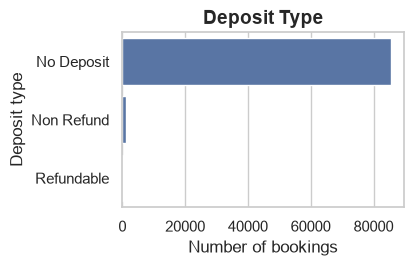

In [45]:
plt.subplot(2, 2, 3)
sns.countplot(y="deposit_type", data=df, order=df["deposit_type"].value_counts().index)
plt.title("Deposit Type")
plt.xlabel("Number of bookings")
plt.ylabel("Deposit type")

98.7% of bookings required no deposit. Guests can cancel at no cost, so there is almost no financial commitment. This is probably the most important number in the chart for our problem. Only about 1% are non-refundable, so there is very little to compare against, which we have to keep in mind later.

Text(0, 0.5, 'Meal plan')

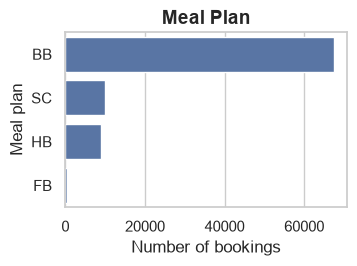

In [46]:
plt.subplot(2, 2, 4)
sns.countplot(y="meal", data=df, order=df["meal"].value_counts().index)
plt.title("Meal Plan")
plt.xlabel("Number of bookings")
plt.ylabel("Meal plan")

Most guests take bed and breakfast (77.8%). Full board (FB) is rare, at 0.4%.

In [47]:
plt.tight_layout()
plt.savefig(VISUALS_DIR / "03_guest_and_booking_types.png")
plt.show()

<Figure size 800x500 with 0 Axes>

arrival_month_num
1     1823
2     2772
3     3791
4     3741
5     3739
6     3487
7     3819
8     4394
9     3836
10    4181
11    3278
12    3105
Name: count, dtype: int64


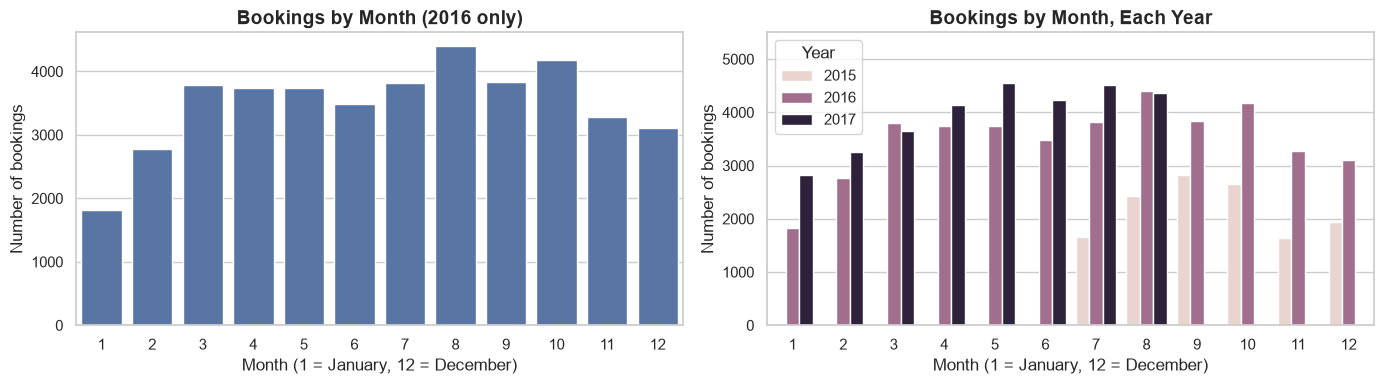

In [48]:
# time patterns: which months are busy, and how bookings changed over the two years. I'll test it first because there is a trap in this dataset.time patterns: which months are busy, and how bookings changed over the two years. I'll test it first because there is a trap in this dataset.


# Step 1: keep only 2016 (the one year that has all 12 months)
df_2016 = df[df["arrival_date_year"] == 2016]

# Step 2: print the numbers
print(df_2016["arrival_month_num"].value_counts().sort_index())

# Step 3: make an empty canvas
plt.figure(figsize=(14, 4))

# Step 4: left chart - 2016 only
plt.subplot(1, 2, 1)
sns.countplot(x="arrival_month_num", data=df_2016)
plt.title("Bookings by Month (2016 only)")
plt.xlabel("Month (1 = January, 12 = December)")
plt.ylabel("Number of bookings")

# Step 5: right chart - every year side by side
plt.subplot(1, 2, 2)
sns.countplot(x="arrival_month_num", hue="arrival_date_year", data=df)
plt.title("Bookings by Month, Each Year")
plt.xlabel("Month (1 = January, 12 = December)")
plt.ylabel("Number of bookings")
plt.ylim(0, 5500)
plt.legend(title="Year", loc="upper left")

# Step 6: tidy up, save, and show
plt.tight_layout()
plt.savefig(VISUALS_DIR / "04_time_patterns.png")
plt.show()


Bookings are seasonal. August is the busiest month, about 2.4 times January.

October is a second peak, so the busy season is more than summer.

November to January is the weak period.


The business is growing: 2017 months are mostly higher than the same months in 2016.


Why 2016 only?

The data runs from July 2015 to August 2017, so July and August appear three times and the other months twice. Counting all rows would make July and August look about 50% busier for no real reason. 2016 is the only full year, so it gives a fair comparison.

In [49]:
# stay length and guests
print(df["total_nights"].describe().round(1))
print("Stays of 7 nights or less (%):", round((df["total_nights"] <= 7).mean() * 100, 1))
print((df["total_guests"].value_counts(normalize=True).sort_index() * 100).round(1).head(6))
print("Bookings with children (%):", round(df["is_family"].mean() * 100, 1))

count    86637.0
mean         3.7
std          2.7
min          1.0
25%          2.0
50%          3.0
75%          5.0
max         69.0
Name: total_nights, dtype: float64
Stays of 7 nights or less (%): 94.4
total_guests
1    18.3
2    65.4
3    11.6
4     4.5
5     0.2
6     0.0
Name: proportion, dtype: float64
Bookings with children (%): 10.5


In [50]:
short_stays = df[df["total_nights"] <= 15]
small_groups = df[df["total_guests"] <= 6]

Text(0, 0.5, 'Number of bookings')

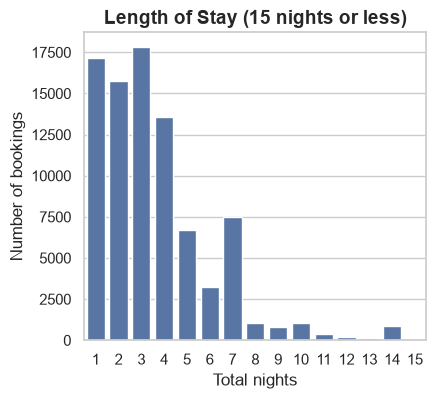

In [51]:
# Step 3: make an empty canvas
plt.figure(figsize=(15, 4))

# Step 4: chart 1 - how many nights
plt.subplot(1, 3, 1)
sns.countplot(x="total_nights", data=short_stays)
plt.title("Length of Stay (15 nights or less)")
plt.xlabel("Total nights")
plt.ylabel("Number of bookings")

Text(0, 0.5, 'Number of bookings')

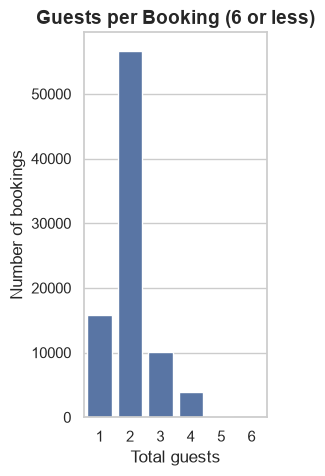

In [52]:
# Step 5: chart 2 - how many guests
plt.subplot(1, 3, 2)
sns.countplot(x="total_guests", data=small_groups)
plt.title("Guests per Booking (6 or less)")
plt.xlabel("Total guests")
plt.ylabel("Number of bookings")


Text(0, 0.5, 'Number of bookings')

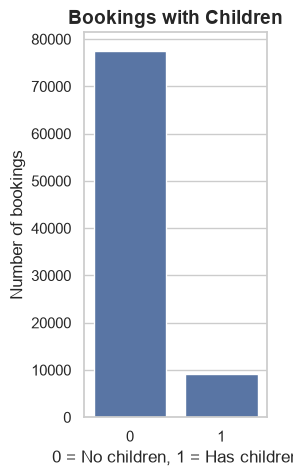

In [53]:
# Step 6: chart 3 - families
plt.subplot(1, 3, 3)
sns.countplot(x="is_family", data=df)
plt.title("Bookings with Children")
plt.xlabel("0 = No children, 1 = Has children")
plt.ylabel("Number of bookings")

1. **Stays are short.**  
   Most guests stay for about **3 nights**, and **94% of stays are 7 nights or less**. This means rooms become available quickly. If a guest cancels, it can be difficult to find another guest to fill that room.

2. **Many guests stay for one week.**  
   There is a noticeable increase in **7-night stays**. This suggests that some guests come for a **one-week holiday**, especially at the Resort Hotel.

3. **Couples are the main customers.**  
   About **65% of bookings are for 2 people**, and **83% are for 1 or 2 people**. This means rooms for **one or two guests are the hotel's main product**.

4. **Families are a smaller group.**  
   Only about **10% of bookings include children**. This means the hotel gets **fewer family bookings** compared with couples and adults traveling without children.



In [54]:
# Step 7: tidy up, save, and show
plt.tight_layout()
plt.savefig(VISUALS_DIR / "05_stay_and_guests.png")
plt.show()

<Figure size 800x500 with 0 Axes>